# Pipelines I: Scripts to Graphs

Alex Ronczewski  
2026-07-30

## Outline

### Prerequisites

-   Notebook 7 of this stream: the OLTP intake system, the star schema
    warehouse, and the ETL connecting them together.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Explain what a mid-run crash does to a batch job, and why
    per-statement transactions do not protect a whole pipeline.
2.  Make a load **idempotent**, so that running it twice is the same as
    running it once.
3.  Write an **incremental** extract that fetches only what is new.
4.  Add **logging** and **retries** to a pipeline, and say when retrying
    is safe.
5.  Represent a pipeline as a **directed acyclic graph** in `networkx`,
    and predict what an executor will run, skip, and refuse.

## 1. Where we are in the stream

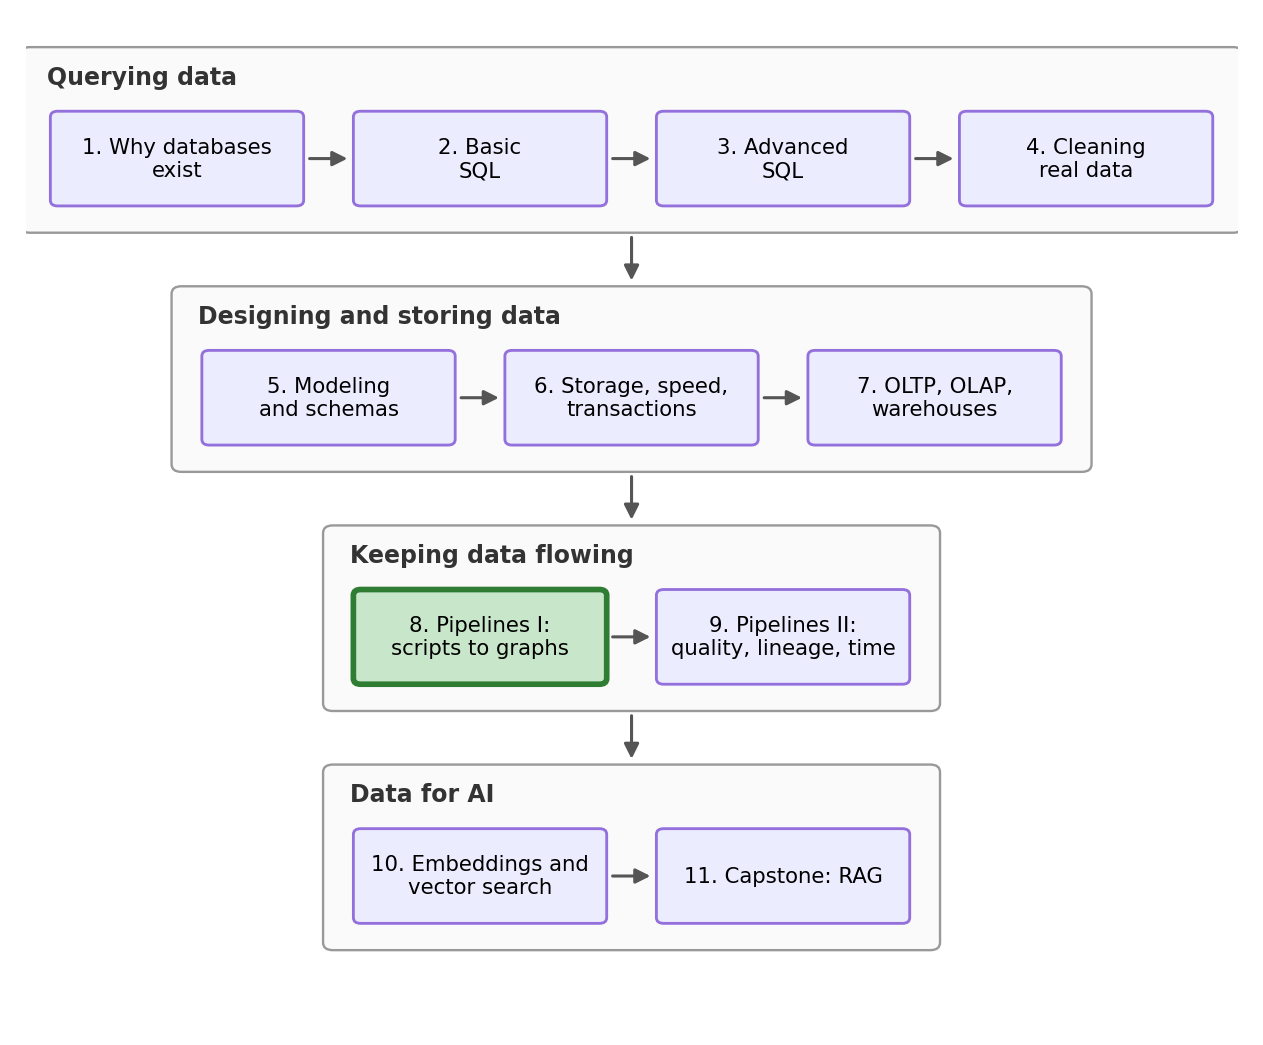

This notebook is the beginning of a big shift. The first seven notebooks
built things that are static: queries, schemas, a warehouse. This
section is about keeping data *moving*, with nobody watching over it
directly. Because after Notebook 7 shipped, the office did the natural
next thing: they put our ETL on a schedule. It ran every night, it
usually printed `success`, and everyone stopped thinking about it.

> **The incident, from the survey office.** “Friday night the warehouse
> update timed out partway, some network thing. The on-call analyst
> re-ran it, and it finished fine. But Monday’s report says September
> had over fifteen thousand responses, and we surveyed about ten
> thousand. The pipeline says success. Please figure out what happened,
> and make it so this cannot happen again.”

This notebook is about answering this email. We will reproduce the whole
incident, learn why the re-run made things worse, and then rebuild the
script the way pipelines are actually built in the real world: safe to
re-run, knowing what content is new, logging its steps, and finally,
restructured as a graph of tasks.

## 2. Re-Running

We rebuild everything from Notebook 7 first, condensed into two long
cells: the simulated wave 2 data with its built-in wage values, and the
two systems: the SQLite intake database and the DuckDB warehouse (if you
need more context revisit Notebook 7). The new piece is that the data
generator is now a function, `simulate_month`, because the data loading
in this notebook is not a one-time event, but rather happens month by
month. In the real world new data keeps arriving constantly and we
mirror that here.

In [1]:
#Import our libraries
import os
import time
import sqlite3
from datetime import datetime
import duckdb
import networkx as nx
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(42)
EDUCATION_PREMIUM = {"High school": 0.00, "College diploma": 0.10, "Bachelor's degree": 0.25, "Graduate degree": 0.40}
UNION_PREMIUM, AGE_PREMIUM, ANNUAL_GROWTH = 0.12, 0.004, 0.03

provinces_df = pd.read_csv("datasets/provinces.csv")
provinces_df.loc[len(provinces_df)] = ["Saskatchewan", "Prairies", 15.00, 1253569]

n_people = 60_000
respondents = pd.DataFrame({
    "respondent_id": np.arange(1, n_people + 1),
    "age": rng.integers(19, 66, n_people),
    "gender": rng.choice(["Woman", "Man", "Nonbinary"], n_people, p=[0.48, 0.48, 0.04]),
    "education": rng.choice(["High school", "College diploma", "Bachelor's degree", "Graduate degree"],
                            n_people, p=[0.30, 0.25, 0.30, 0.15]),
    "union_member": rng.integers(0, 2, n_people),
    "industry": rng.choice(["Construction", "Education", "Finance", "Health care", "Hospitality",
                            "Manufacturing", "Public administration", "Retail", "Technology"], n_people),
    "province": rng.choice(provinces_df["province"], n_people,
                           p=provinces_df["population"] / provinces_df["population"].sum()),
})

def simulate_month(first_day, days_in_month, first_id, n):
    batch = pd.DataFrame({
        "response_id": np.arange(first_id, first_id + n),
        "respondent_id": rng.integers(1, n_people + 1, n),
        "interview_date": pd.Timestamp(first_day) + pd.to_timedelta(rng.integers(0, days_in_month, n), unit="D"),
        "weekly_hours": rng.normal(37, 6, n).clip(5, 80).round(1),
    })
    traits = batch.merge(respondents, on="respondent_id")
    years_in = (traits["interview_date"] - pd.Timestamp("2026-09-01")).dt.days / 365
    log_wage = (3.2 + traits["education"].map(EDUCATION_PREMIUM) + UNION_PREMIUM * traits["union_member"]
                + AGE_PREMIUM * traits["age"] + ANNUAL_GROWTH * years_in + rng.normal(0, 0.25, n))
    batch["hourly_wage"] = np.exp(log_wage).clip(17.40, None).round(2)
    batch["interview_date"] = batch["interview_date"].dt.strftime("%Y-%m-%d")
    return batch

history = simulate_month("2026-09-01", 730, 1, 250_000)
print(f"mean wage = {history['hourly_wage'].mean():.2f}")

mean wage = 38.99

The same 250,000 responses as Notebook 7, with a mean wage of 38.99. Now
both systems, and one small improvement while we are here: the initial
load writes the `dim_date` with the *full calendar* through the end of
2028. This is a common warehouse habit, so arriving months never need to
touch the calendar again and just fit to it.

In [3]:
op = sqlite3.connect("datasets/wage_wave2.db")
op.execute("PRAGMA foreign_keys = ON")
op.execute("DROP TABLE IF EXISTS response")
op.execute("DROP TABLE IF EXISTS respondent")
op.execute("DROP TABLE IF EXISTS province")
op.execute("""CREATE TABLE province (province TEXT PRIMARY KEY, region TEXT NOT NULL,
    minimum_wage REAL NOT NULL CHECK (minimum_wage > 0), population INTEGER NOT NULL CHECK (population > 0)) STRICT""")
op.execute("""CREATE TABLE respondent (respondent_id INTEGER PRIMARY KEY,
    age INTEGER NOT NULL CHECK (age BETWEEN 15 AND 100), gender TEXT NOT NULL, education TEXT NOT NULL,
    union_member INTEGER NOT NULL CHECK (union_member IN (0, 1)), industry TEXT NOT NULL,
    province TEXT NOT NULL REFERENCES province(province)) STRICT""")
op.execute("""CREATE TABLE response (response_id INTEGER PRIMARY KEY,
    respondent_id INTEGER NOT NULL REFERENCES respondent(respondent_id), interview_date TEXT NOT NULL,
    weekly_hours REAL NOT NULL CHECK (weekly_hours BETWEEN 0 AND 100),
    hourly_wage REAL NOT NULL CHECK (hourly_wage > 0)) STRICT""")
op.execute("CREATE INDEX idx_response_respondent ON response(respondent_id)")
provinces_df.to_sql("province", op, index=False, if_exists="append")
respondents.to_sql("respondent", op, index=False, if_exists="append")
history.to_sql("response", op, index=False, if_exists="append")

warehouse = duckdb.connect("datasets/wage_warehouse.duckdb")

people = pd.read_sql("SELECT * FROM respondent", op)
first_fact = history.merge(people[["respondent_id", "province"]], on="respondent_id")
first_fact["full_time"] = (first_fact["weekly_hours"] >= 30).astype(int)
first_fact = first_fact.rename(columns={"interview_date": "date"})[
    ["response_id", "respondent_id", "province", "date", "full_time", "weekly_hours", "hourly_wage"]]

calendar = pd.DataFrame({"date": pd.date_range("2026-09-01", "2028-12-31").strftime("%Y-%m-%d")})
days = pd.to_datetime(calendar["date"])
calendar["year"] = days.dt.year
calendar["month"] = days.dt.month
calendar["year_month"] = days.dt.strftime("%Y-%m")
calendar["quarter"] = days.dt.quarter

warehouse.execute("CREATE OR REPLACE TABLE fact_response AS SELECT * FROM first_fact")
warehouse.execute("CREATE OR REPLACE TABLE dim_respondent AS SELECT * FROM people")
warehouse.execute("CREATE OR REPLACE TABLE dim_province AS SELECT * FROM provinces_df")
warehouse.execute("CREATE OR REPLACE TABLE dim_date AS SELECT * FROM calendar")
warehouse.execute("""CREATE OR REPLACE TABLE monthly_report AS
    SELECT d.year_month, COUNT(*) AS responses, ROUND(AVG(f.hourly_wage), 2) AS avg_wage
    FROM fact_response AS f JOIN dim_date AS d ON f.date = d.date
    GROUP BY d.year_month ORDER BY d.year_month""")

warehouse.execute("SELECT * FROM monthly_report ORDER BY year_month DESC LIMIT 3").df()

The warehouse is healthy through August 2028: a little over ten thousand
responses a month, wages drifting up on the trend we built in.

Now we simulate September. Interviews pour into the intake system all
month, which we replay in one short cell:

In [4]:
september = simulate_month("2028-09-01", 30, 250_001, 10_400)
september.to_sql("response", op, index=False, if_exists="append")

print("intake system:", pd.read_sql("SELECT COUNT(*) FROM response", op).iloc[0, 0], "responses")
print("warehouse:", warehouse.execute("SELECT COUNT(*) FROM fact_response").df().iloc[0, 0], "responses")

intake system: 260400 responses
warehouse: 250000 responses

260,400 responses in the operational system, 250,000 in the warehouse.
The gap between them is the new September entries; we use the nightly
script to close this gap.

## 3. The night of the crash

Here is the monthly update as the office scheduled it, Notebook 7’s ETL
(Extract, Transform, Load) aimed at our new month. We pull everything
from September onward from the intake system (with Notebook 3’s `?`
placeholder carrying the date), add provinces and the full-time dummy
variable, and append it to the fact table in our analyst database.

In [5]:
pulled = pd.read_sql("SELECT * FROM response WHERE interview_date >= ?", op, params=("2028-09-01",))

sept_fact = pulled.merge(people[["respondent_id", "province"]], on="respondent_id")
sept_fact["full_time"] = (sept_fact["weekly_hours"] >= 30).astype(int)
sept_fact = sept_fact.rename(columns={"interview_date": "date"})[
    ["response_id", "respondent_id", "province", "date", "full_time", "weekly_hours", "hourly_wage"]]

print(f"{len(sept_fact)} rows extracted and transformed")

10400 rows extracted and transformed

The load runs in two chunks, half the month at a time (this is how real
systems do it so memory stays flat and the progress is visible from the
outside). This chunking is where the problem occurs. Notebook 6 proved
that a single `INSERT` is atomic, all or nothing, and that promise still
holds. But a batch job is *many* statements, often across systems no
transaction can span, and per-statement atomicity does not necessarily
imply per-job atomicity. Chunk one can be atomic, and the job can still
half-happen due to chunk two or three.

The paragraph above raises one logical question we need to answer first
(and most likely many of you are thinking this): “why not then load the
whole month as one statement and stay atomic?” At our size that would
work, but it’s a band-aid fix, because the *job* is still several
statements with gaps between them: the crash can just as easily land
between the load and the report refresh, or between the extract and the
load, and one of those steps completing without the others is the same
half-happened job. And at real production scale in the real world, the
single-statement option disappears altogether: a billion-row insert held
open in one transaction is an actual nightmare.

Friday, 3:14 a.m. Chunk one succeeds, and then the network to the
warehouse drops. Tonight, we pretend to be the network by throwing an
error on purpose.

In [6]:
first_half = sept_fact.iloc[:5200]
warehouse.execute("INSERT INTO fact_response SELECT * FROM first_half")

raise TimeoutError("03:14 network to the warehouse dropped")

The script is dead, and this is what it left behind:

In [7]:
warehouse.execute("SELECT COUNT(*) AS september_rows FROM fact_response WHERE date >= '2028-09-01'").df()

Half of our September batch: 5,200 rows, committed correctly, but no
error message shows us what happened. Every statement that ran kept its
atomic promise, and the job still half-happened.

> **Predict first.** Saturday morning, the on-call analyst sees the
> failure alert and does what every one of us would do: run the whole
> script again. It finishes without an error this time. September really
> had 10,400 responses. After the re-run, how many September rows does
> the warehouse hold?

In [8]:
pulled = pd.read_sql("SELECT * FROM response WHERE interview_date >= ?", op, params=("2028-09-01",))
retry_fact = pulled.merge(people[["respondent_id", "province"]], on="respondent_id")
retry_fact["full_time"] = (retry_fact["weekly_hours"] >= 30).astype(int)
retry_fact = retry_fact.rename(columns={"interview_date": "date"})[
    ["response_id", "respondent_id", "province", "date", "full_time", "weekly_hours", "hourly_wage"]]

first_half, second_half = retry_fact.iloc[:5200], retry_fact.iloc[5200:]
warehouse.execute("INSERT INTO fact_response SELECT * FROM first_half")
warehouse.execute("INSERT INTO fact_response SELECT * FROM second_half")
warehouse.execute("""CREATE OR REPLACE TABLE monthly_report AS
    SELECT d.year_month, COUNT(*) AS responses, ROUND(AVG(f.hourly_wage), 2) AS avg_wage
    FROM fact_response AS f JOIN dim_date AS d ON f.date = d.date
    GROUP BY d.year_month ORDER BY d.year_month""")

warehouse.execute("""SELECT COUNT(*) AS rows, COUNT(DISTINCT response_id) AS real_responses
                     FROM fact_response WHERE date >= '2028-09-01'""").df()

15,600 rows for 10,400 real responses. The crashed run’s half-month is
still in the database (the 5,200 half-completed rows). Nothing failed,
no errors were raised, and the monthly report is now incorrect:

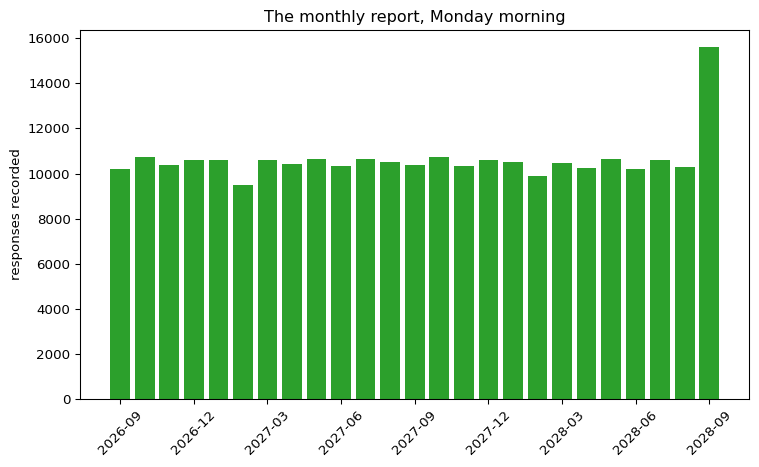

In [9]:
report = warehouse.execute("SELECT * FROM monthly_report ORDER BY year_month").df()

plt.figure(figsize=(9, 5))
plt.bar(report["year_month"], report["responses"], color="tab:green")
plt.xticks(range(0, len(report), 3), rotation=45)
plt.ylabel("responses recorded")
plt.title("The monthly report, Monday morning")
plt.show()

September is fifty percent over every other month in the number of
survey responses. We have diagnosed the problem and properly re-created
it. Let’s now look at fixing it.

## 4. Running it twice must equal running it once

Saturday’s retry was the correct instinct, and Saturday’s analyst did
their job: rerunning is the standard response to a failure like this.
The issue is in the load itself, which was unsafe to rerun. The property
it was missing has a name:

> **Idempotent**
>
> A task is **idempotent** if running it twice leaves the world exactly
> as running it once would: the second run changes nothing. Idempotency
> is the pipeline’s answer to the transaction. Notebook 6’s engine
> guarantees all-or-nothing per statement; nobody guarantees it per job,
> so we design the job so that *partial + retry = correct*. Once every
> task is idempotent, the fix is always the same: run it again.

For a load, the standard construction is **delete-then-insert, scoped to
the batch**: first delete whatever the warehouse holds for the month
being loaded, then insert the month fresh. If the previous run finished,
the delete clears it and the insert replaces it. If the previous run
half-finished, the delete clears the debris. If this run dies after the
delete, the next run deletes nothing and inserts everything. It all
leads to the same outcome. The job is idempotent.

In [10]:
def load_month(fact_batch, month):
    warehouse.execute("DELETE FROM fact_response WHERE date LIKE ?", [month + "%"])
    warehouse.execute("INSERT INTO fact_response SELECT * FROM fact_batch")

load_month(retry_fact, "2028-09")

warehouse.execute("""SELECT COUNT(*) AS rows, COUNT(DISTINCT response_id) AS real_responses
                     FROM fact_response WHERE date >= '2028-09-01'""").df()

10,400 and 10,400. Notice what just happened: the fixed loader loaded
correctly *and repaired the corruption on the way*, because the delete
swept out all 15,600 damaged rows before inserting the clean month. That
is an amazing characteristic of idempotent design: recovery and normal
operation are the same code path. You might be skeptical, so for fun
let’s run it again and see.

In [11]:
load_month(retry_fact, "2028-09")

print(warehouse.execute("SELECT COUNT(*) FROM fact_response WHERE date >= '2028-09-01'").df().iloc[0, 0],
      "rows even after running it twice")

10400 rows even after running it twice

Same 10,400 rows, not 20,800 or some value in between. Exactly what we
are looking for.

## 5. When it breaks anyway

Networks will still drop no matter what improvements we make, so a
pipeline that runs at 3 a.m. needs a diary to keep track of what
happened while the engineers are asleep. Ours will be tiny, stamping
each message with the time (`datetime.now()` reads the current time):

In [12]:
def log(message):
    print(f"[{datetime.now().strftime('%H:%M:%S')}] {message}")

For the transient failures, the standard protocol is a **retry
wrapper**; we need a bit of new code logic for this. In Python we use a
`try`/`except` block. First it runs what `try` points to, and if
anything raises an error, instead of dying and terminating, it jumps to
the `except` block while holding the error. We have spent seven
notebooks reading errors; this is the first time we catch one. Inside
the wrapper, `task.__name__` lets a function report its own name to the
log.

In [13]:
def with_retries(task, attempts):
    for attempt in range(1, attempts + 1):
        try:
            task()
            log(f"{task.__name__}: succeeded on attempt {attempt}")
            return
        except Exception as error:
            log(f"{task.__name__}: attempt {attempt} failed ({error})")
    raise RuntimeError(f"{task.__name__}: gave up after {attempts} attempts")

failures_left = [2]                       # a one-item list we count down: fail twice, then work

def flaky_network_copy():
    if failures_left[0] > 0:
        failures_left[0] = failures_left[0] - 1
        raise TimeoutError("connection dropped")

with_retries(flaky_network_copy, attempts=4)

[21:21:43] flaky_network_copy: attempt 1 failed (connection dropped)
[21:21:43] flaky_network_copy: attempt 2 failed (connection dropped)
[21:21:43] flaky_network_copy: succeeded on attempt 3

Two failures absorbed by the wrapper, with a success on the third try,
and the log tells the whole story with timestamps to whoever reads it at
work on Monday.

## 6. The arrows are the program

Step back and look at what our script has now become: an extraction of
new responses, an extraction of respondents, a transform that needs
both, a load that needs the transform, a report that needs the load, and
an archive step that needs only the raw extract. We have been writing it
top to bottom like Python and a Jupyter Notebook imply, but the truth is
that the top-to-bottom order was an accident. Nothing about *extract
respondents* requires it to run after *extract responses*; they touch
different tables and could run in either order, or at the same time on
different machines. The real program is the arrows which exist beneath
it:

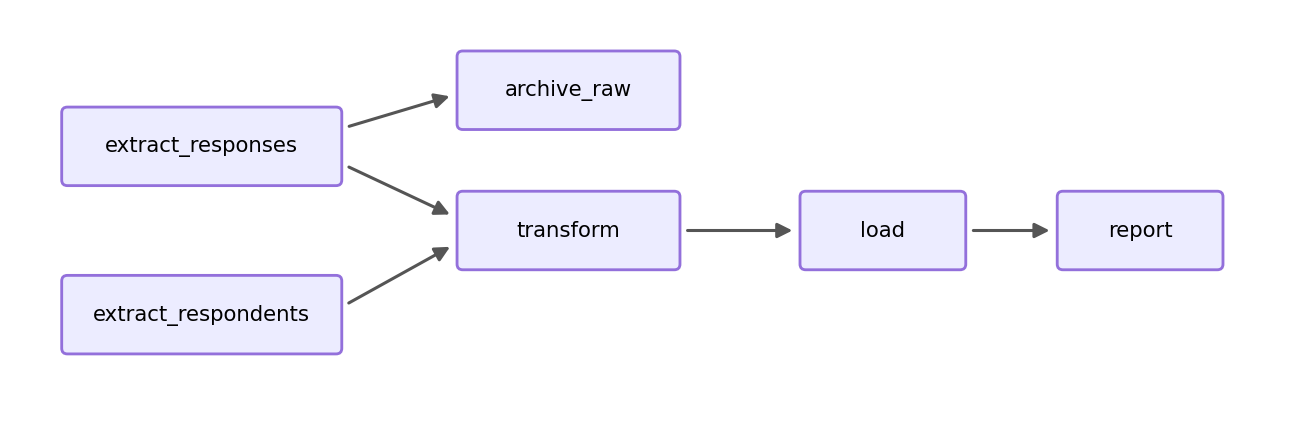

Let’s make our whole system bullet-proof. First, the tasks themselves:
each one becomes a small named function. We make sure every task is
idempotent: the extracts and transform rebuild staging tables with
`CREATE OR REPLACE`, the load is delete-then-insert, the report is a
full rebuild, and the archive writes one file per month, so re-archiving
a month rewrites its file and an empty night writes nothing. Second,
tasks hand data to each other through *storage*, staging tables and
files, never through Python variables, which is what lets tomorrow’s
run, or another machine, pick up exactly where any task left off.

In [14]:
def extract_responses():
    watermark = warehouse.execute("SELECT MAX(date) FROM fact_response").df().iloc[0, 0]
    pulled = pd.read_sql("SELECT * FROM response WHERE interview_date > ?", op, params=(watermark,))
    warehouse.execute("CREATE OR REPLACE TABLE staging_responses AS SELECT * FROM pulled")
    log(f"extract_responses: {len(pulled)} new rows")

def extract_respondents():
    people_now = pd.read_sql("SELECT * FROM respondent", op)
    warehouse.execute("CREATE OR REPLACE TABLE staging_respondents AS SELECT * FROM people_now")
    log(f"extract_respondents: {len(people_now)} rows")

def archive_raw():
    batch = warehouse.execute("SELECT * FROM staging_responses").df()
    if len(batch) == 0:
        log("archive_raw: nothing new to archive")
        return
    month = batch["interview_date"].min()[:7]              
    batch.to_parquet(f"datasets/archive_{month}.parquet")
    log(f"archive_raw: {len(batch)} rows to the lake ({month})")

def transform():
    warehouse.execute("""CREATE OR REPLACE TABLE staging_fact AS
        SELECT s.response_id, s.respondent_id, r.province,
               CAST(s.interview_date AS VARCHAR) AS date,          -- pin the type, even on an empty night
               CASE WHEN s.weekly_hours >= 30 THEN 1 ELSE 0 END AS full_time,
               s.weekly_hours, s.hourly_wage
        FROM staging_responses AS s
        JOIN staging_respondents AS r ON s.respondent_id = r.respondent_id""")
    log("transform: staging_fact rebuilt")

def load():
    warehouse.execute("""DELETE FROM fact_response WHERE substr(date, 1, 7) IN
                         (SELECT DISTINCT substr(date, 1, 7) FROM staging_fact)""")
    warehouse.execute("INSERT INTO fact_response SELECT * FROM staging_fact")
    log("load: fact_response up to date")

def report():
    warehouse.execute("""CREATE OR REPLACE TABLE monthly_report AS
        SELECT d.year_month, COUNT(*) AS responses, ROUND(AVG(f.hourly_wage), 2) AS avg_wage
        FROM fact_response AS f JOIN dim_date AS d ON f.date = d.date
        GROUP BY d.year_month ORDER BY d.year_month""")
    log("report: monthly_report refreshed")

We will now visualize our script as an object with arrows. A pipeline
drawn as boxes and arrows is called a **directed graph** in mathematics.
Tasks are boxes (nodes), dependencies are arrows (edges), and each edge
points from a task to the task that needs it. The go-to Python library
for graphs is `networkx` (the same library behind the [prAxIs network
analysis
materials](https://ubcecon.github.io/praxis-ubc/docs/SOCI-415/soci_415_network_analysis.html),
where it maps kinship in families instead of tasks). If you would like
to learn more about network analysis and NetworkX, have a look.

We focus on two main `networkx` commands. `is_directed_acyclic_graph`
checks that no task, followed forward along its arrows, ever leads back
to itself; a graph that passes is a **DAG**, a directed acyclic graph,
and acyclicity makes running the pipeline *possible*: if A needs B and B
needs A, there is no order in which to start and it will loop forever.
And `topological_sort` produces a valid running order, every task after
everything it depends on.

In [15]:
pipeline = nx.DiGraph()
pipeline.add_edges_from([
    ("extract_responses", "transform"),
    ("extract_respondents", "transform"),
    ("extract_responses", "archive_raw"),
    ("transform", "load"),
    ("load", "report"),
])

print("acyclic:", nx.is_directed_acyclic_graph(pipeline))
print("one possible valid order:", list(nx.topological_sort(pipeline)))

acyclic: True
one possible valid order: ['extract_responses', 'extract_respondents', 'archive_raw', 'transform', 'load', 'report']

Our pipeline is a DAG just like the flowchart above showed us! Compare
that order to the script we have been writing throughout this notebook:
our top-to-bottom sequence was a topological sort of this graph all
along. Here the printed order happens to come out identical to ours, but
any order that respects the arrows would be equally valid. Drawing the
graph makes the shape easier to talk about.

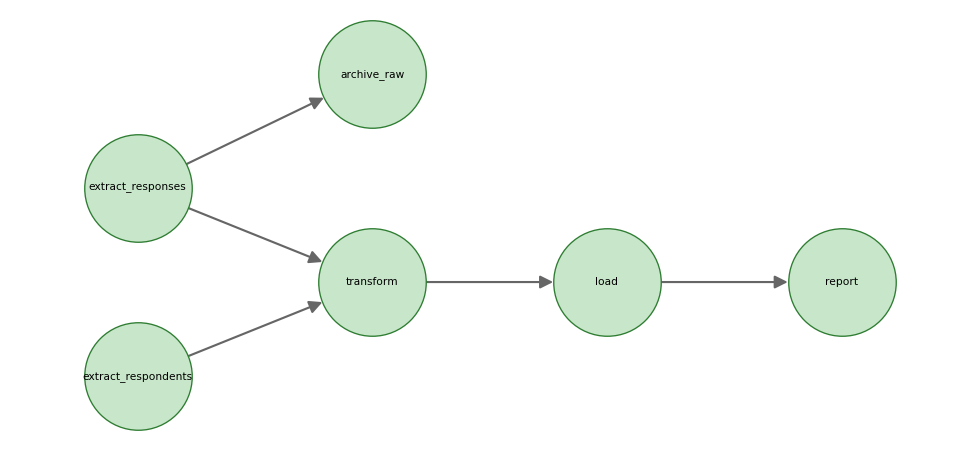

In [16]:
positions = {"extract_responses": (0, 1), "extract_respondents": (0, 0), "archive_raw": (1.1, 1.6),
             "transform": (1.1, 0.5), "load": (2.2, 0.5), "report": (3.3, 0.5)}

plt.figure(figsize=(10, 4.5))
nx.draw(pipeline, positions, with_labels=True, node_color="#c8e6c9", edgecolors="#2e7d32",
        node_size=6500, font_size=8, edge_color="#666666", arrowsize=20, width=1.6)
plt.margins(x=0.12, y=0.15)
plt.show()

This is an elegant visualization of our rather simple pipeline. These
pipelines can become really complex; here is an example:

<figure>
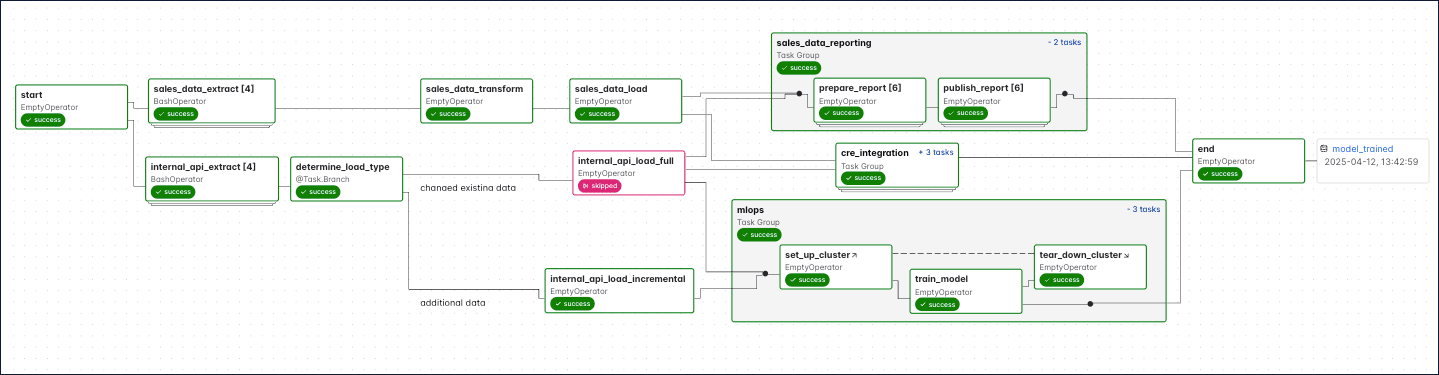
<figcaption aria-hidden="true">A complex production DAG in Apache
Airflow.</figcaption>
</figure>

I have a little secret which I have been hiding since Notebook 1. Scroll
up to the map in section 1: eleven notebooks, arrows showing what
depends on what, no arrow ever pointing backward. The “you are here”
diagram you have followed through this whole stream is a directed
acyclic graph, and we have been executing it, one node per lesson, in
topological order.

The real program was always the arrows; the lines of code were just one
way of walking them.

## 7. The executor

If the graph is the program, then running the pipeline means walking the
graph. Here is a small executor, reading it *is* the exercise, because
every industrial orchestrator (like Apache Airflow) is this loop just
with more steps, checks and tasks. It refuses graphs with cycles, visits
tasks in topological order, runs each one, and if a task fails, it skips
everything downstream of the failure while letting independent branches
finish.

In [17]:
def run_pipeline(graph, tasks):
    if not nx.is_directed_acyclic_graph(graph):
        raise ValueError("this graph has a cycle: no run order exists")
    finished, failed, skipped = [], [], []
    for name in nx.topological_sort(graph):
        blocked = [task for task in graph.predecessors(name) if task in failed or task in skipped]
        if blocked:
            skipped.append(name)
            log(f"SKIP {name} (upstream trouble: {blocked[0]})")
            continue
        try:
            tasks[name]()
            finished.append(name)
        except Exception as error:
            failed.append(name)
            log(f"FAIL {name}: {error}")
    return finished, failed, skipped

tasks = {"extract_responses": extract_responses, "extract_respondents": extract_respondents,
         "archive_raw": archive_raw, "transform": transform, "load": load, "report": report}

October arrives, and the monthly update is now one call:

In [18]:
october = simulate_month("2028-10-01", 31, 260_401, 10_400)
october.to_sql("response", op, index=False, if_exists="append")

run_pipeline(pipeline, tasks)

warehouse.execute("SELECT * FROM monthly_report ORDER BY year_month DESC LIMIT 3").df()

[21:21:43] extract_responses: 10400 new rows
[21:21:44] extract_respondents: 60000 rows
[21:21:44] archive_raw: 10400 rows to the lake (2028-10)
[21:21:44] transform: staging_fact rebuilt
[21:21:44] load: fact_response up to date
[21:21:44] report: monthly_report refreshed

Six new lines in our log with timestamps, six tasks completed, 270,800
observations in our database, October’s data is sitting cleanly on top
at 10,400 responses. We run it again, when nothing new has arrived, and
the whole architecture starts really showing its worth:

In [19]:
run_pipeline(pipeline, tasks)

print(warehouse.execute("SELECT COUNT(*) FROM fact_response").df().iloc[0, 0], "facts, unchanged")

[21:21:44] extract_responses: 0 new rows
[21:21:44] extract_respondents: 60000 rows
[21:21:44] archive_raw: nothing new to archive
[21:21:44] transform: staging_fact rebuilt
[21:21:44] load: fact_response up to date
[21:21:44] report: monthly_report refreshed
270800 facts, unchanged

Zero new rows extracted, and nothing loaded twice. Incremental extracts
and idempotent loads made re-running so safe that the executor does not
even need to know whether tonight is a real night or a retry. We could
run it 500 times for fun and it would not matter.

Now we try to sabotage it, twice. First, a cycle: suppose someone
decides the extract should wait for the report, “so we only pull data
after the numbers are out.”

In [20]:
looped = pipeline.copy()
looped.add_edge("report", "extract_responses")

run_pipeline(looped, tasks)

**ValueError: this graph has a cycle: no run order exists**. Refused
outright with a clear error, before a single task ran. The report now
waits for the extract and the extract waits for the report; there is no
first move, and the executor’s opening check lets us know instead of
running forever.

Second sabotage: a failure in the middle of the graph. We swap in a
transform that dies, the kind of thing a renamed upstream column might
cause, and watch what the graph does with the damage:

In [21]:
def broken_transform():
    raise RuntimeError("upstream renamed a column")

tasks_broken = dict(tasks)
tasks_broken["transform"] = broken_transform

run_pipeline(pipeline, tasks_broken)

[21:21:44] extract_responses: 0 new rows
[21:21:44] extract_respondents: 60000 rows
[21:21:44] archive_raw: nothing new to archive
[21:21:44] FAIL transform: upstream renamed a column
[21:21:44] SKIP load (upstream trouble: transform)
[21:21:44] SKIP report (upstream trouble: load)

(['extract_responses', 'extract_respondents', 'archive_raw'],
 ['transform'],
 ['load', 'report'])

Read the log carefully. Both extracts ran, the archive still ran,
because it is connected to `extract_responses` and can run correctly
without the broken transform, and `load` and `report` were skipped, not
failed: they never executed at all because transform failed, so the
warehouse still holds exactly 270,800 correct facts. The graph is more
than a visual of the pipeline. It just isolated an issue and *contained
the blast*. Our wonderful DAG knows the difference between downstream
and unrelated and can stop issues from spreading.

## 8. Conclusion

The incident is closed and will never occur again. What happened: the
load was chunked, chunk one committed before a network failure, and the
retry stacked a full month onto the surviving half, because
per-statement transactions do not protect multi-statement jobs. Why it
will not happen again: the load is now idempotent, so any retry, human
or automated, lands on the same correct state; the extract is
incremental, so nobody edits dates into the script; failures are logged
and retried by a wrapper that is safe because the tasks under it are
idempotent; and the whole update is a DAG walked by an executor that
refuses cycles, and contains failures.

That executor is also your first step into a job in the proper data
industry. Enterprise solutions like Airflow, Prefect, Dagster, and dbt’s
DAG runner are, more or less, section 7’s twenty lines with schedulers,
retries, and dashboards attached to them. When a job posting says
“orchestration experience,” it is naming this notebook. What none of
that machinery can catch is the failure that does not raise an error.
The pipeline that runs green while the data inside it goes wrong.
Notebook 9 is the next part: a new month arrives subtly broken, every
task succeeds, and “the pipeline ran” and “the data is right” now do not
mean the same thing.

> **You can now answer these interview questions**
>
> -   What does it mean for a pipeline task to be idempotent, and why
>     does it matter?
> -   Your nightly job died halfway through last night. What should
>     re-running it do, and what does that require?
> -   Why are pipelines modelled as DAGs, and what must an orchestrator
>     refuse to run?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   Running it twice leaves the same state as running it once. It
>     matters because crashes and retries happen in the real world, and
>     a retry with a non-idempotent task duplicates data.
> -   Re-running should produce exactly the state a clean single run
>     would have produced, which requires every task to be idempotent;
>     then recovery is just “run it again,” with no manual cleanup.
> -   Tasks depend on other tasks, and the dependency structure, a
>     directed graph, determines what can run, in what order, and what a
>     failure poisons. An orchestrator must refuse cycles, since a
>     cyclic graph has no valid execution order at all.
>
> </details>

## Connections

-   **Back to [Notebook 7](notebook_07_two_kinds_of_databases.qmd):**
    the ETL that ran because we babysat it is now a pipeline that runs
    alone.
-   **Forward to [Notebook 9](notebook_09_pipelines_two.qmd):**
    everything here protects against jobs that *fail*. Next we fight a
    harder invisible enemy: a job that succeeds on broken data.
    Validation checks that halt the pipeline, lineage that traces what a
    bad file poisoned, and time, schedules, and backfills.

### References

-   Hagberg, A., Schult, D., & Swart, P. (2008). *Exploring network
    structure, dynamics, and function using NetworkX.* Proceedings of
    the 7th Python in Science Conference. The graph library behind
    sections 6 and 7.
-   Apache Software Foundation. *Apache Airflow concepts: DAGs.*
    https://airflow.apache.org/docs/apache-airflow/stable/core-concepts/dags.html
    The industrial version of section 7’s executor, whose core object is
    literally called a DAG.
-   Astronomer. *Airflow guides.* https://www.astronomer.io/docs/learn/
    The most readable free material on orchestration practice, including
    idempotency and retries.
-   Kleppmann, M. (2017). *Designing Data-Intensive Applications.*
    O’Reilly. Chapter 10 on batch processing: why jobs are designed to
    be re-runnable, at much larger scale than ours.
-   Munroe, R. *Data pipeline.* xkcd 2054. https://xkcd.com/2054/ The
    pipeline this notebook is trying to save you from building.

------------------------------------------------------------------------